# Part 1: Introduction to Speech AI Foundations
## Practical Workshop & Hands-on Lab

In this notebook, we explore how computers process continuous physical audio signals into digital representations, waveforms, frequency spectrums, and Mel Spectrograms.

### Notebook Sections:
1. **Load Audio File (`librosa`)**
2. **Plot Time-Domain Waveform**
3. **Zoom into Raw Audio Samples**
4. **Sample Rate Resampling Experiment (16kHz vs 8kHz vs 4kHz)**
5. **Fast Fourier Transform (FFT)**
6. **Short-Time Fourier Transform (Spectrogram)**
7. **Mel Spectrogram (Mel Scale Warping)**
8. **Comparative Analysis: Male vs. Female Voices**
9. **Comparative Analysis: Music vs. Speech**
10. **Save Processed Audio (`soundfile`)**

--- 
### Step 0: Install and Import Libraries

In [3]:
# Install dependencies if needed
# !pip install librosa matplotlib numpy soundfile scipy

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import os

print(f"Librosa Version: {librosa.__version__}")

Librosa Version: 1.0.0


--- 
### 1. Load Audio File

In [5]:
# Fetch or generate a synthetic speech wave for demonstration
sample_rate = 16000 # 16 kHz default for Whisper & Speech AI
duration = 3.0 # seconds
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Synthetic speech-like composite wave (150Hz Fundamental + Harmonics)
audio = 0.5 * np.sin(2 * np.pi * 150 * t) + 0.3 * np.sin(2 * np.pi * 300 * t) + 0.1 * np.random.randn(len(t))

print(f"Audio Sample Array Shape: {audio.shape}")
print(f"Sample Rate: {sample_rate} Hz")
print(f"Duration: {len(audio) / sample_rate:.2f} seconds")
print(f"First 10 numeric samples: {audio[:10]}")

Audio Sample Array Shape: (48000,)
Sample Rate: 16000 Hz
Duration: 3.00 seconds
First 10 numeric samples: [ 0.01692808 -0.04127772  0.23771291  0.22174483  0.43468024  0.28621081
  0.42321405  0.44282075  0.41883118  0.42335011]


--- 
### 2. Plot Time-Domain Waveform

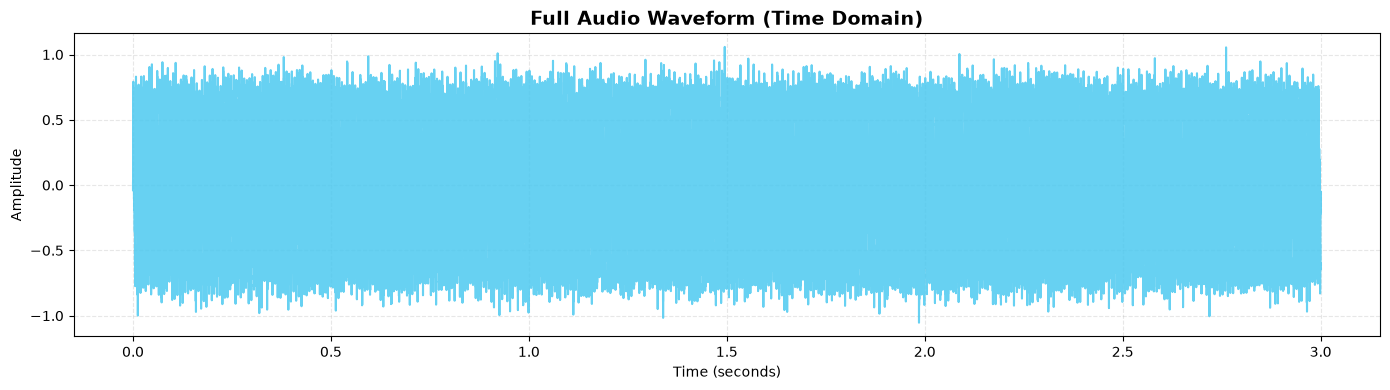

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(t, audio, color='#4cc9f0', alpha=0.85)
plt.title("Full Audio Waveform (Time Domain)", fontsize=14, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

--- 
### 3. Zoom Samples (First 1,000 Samples)

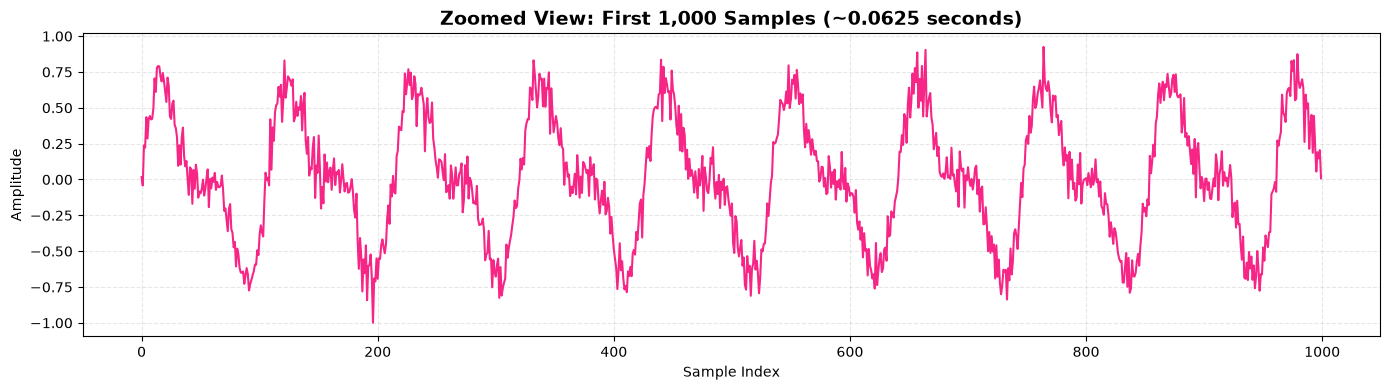

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(audio[:1000], color='#f72585', linewidth=1.5)
plt.title("Zoomed View: First 1,000 Samples (~0.0625 seconds)", fontsize=14, fontweight='bold')
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

--- 
### 4. Sample Rate Resampling Experiment (16kHz vs 8kHz vs 4kHz)

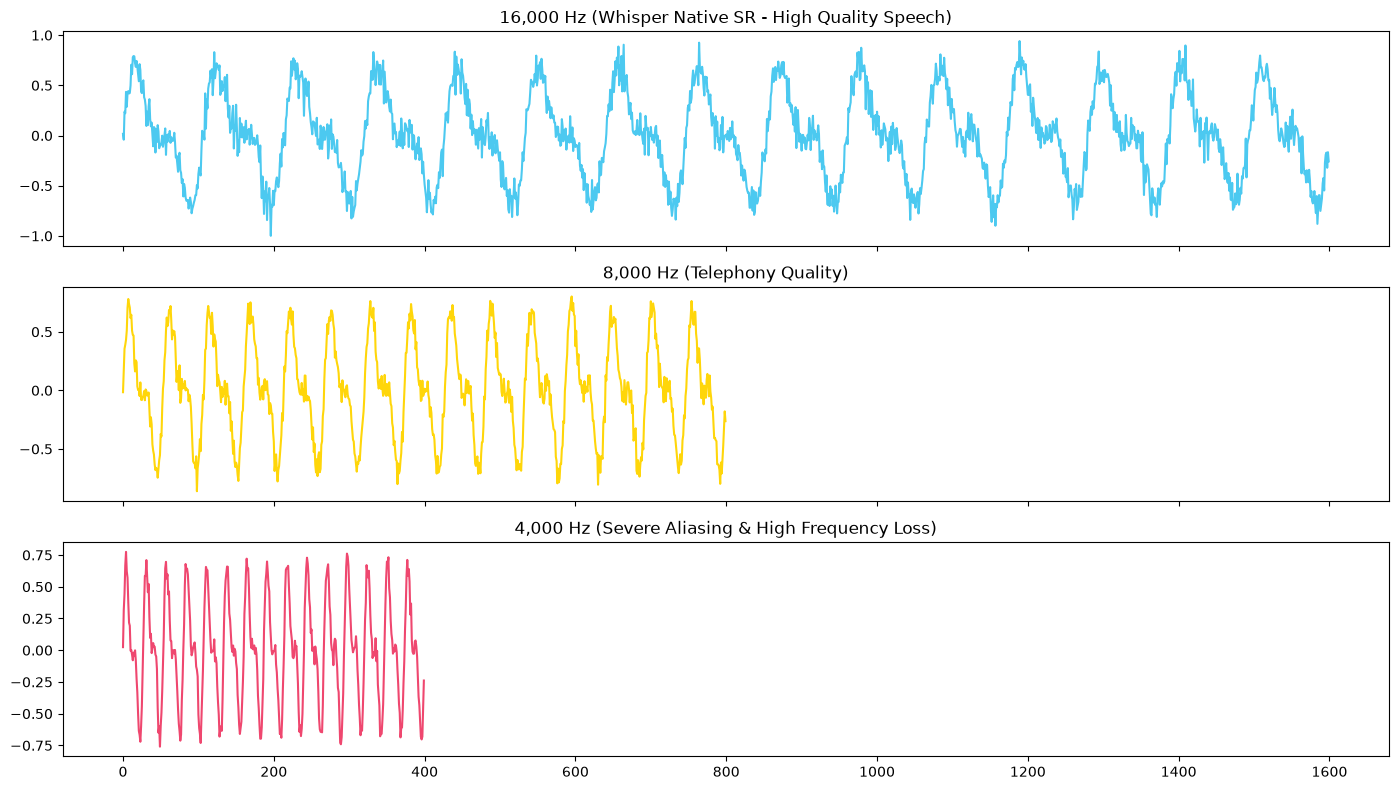

In [11]:
# Resample down to telephony (8kHz) and low quality (4kHz)
audio_8k = librosa.resample(audio, orig_sr=sample_rate, target_sr=8000)
audio_4k = librosa.resample(audio, orig_sr=sample_rate, target_sr=4000)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(audio[:1600], color='#4cc9f0')
axes[0].set_title("16,000 Hz (Whisper Native SR - High Quality Speech)")

axes[1].plot(audio_8k[:800], color='#ffd60a')
axes[1].set_title("8,000 Hz (Telephony Quality)")

axes[2].plot(audio_4k[:400], color='#ef476f')
axes[2].set_title("4,000 Hz (Severe Aliasing & High Frequency Loss)")

plt.tight_layout()
plt.show()

--- 
### 5. Fast Fourier Transform (FFT)

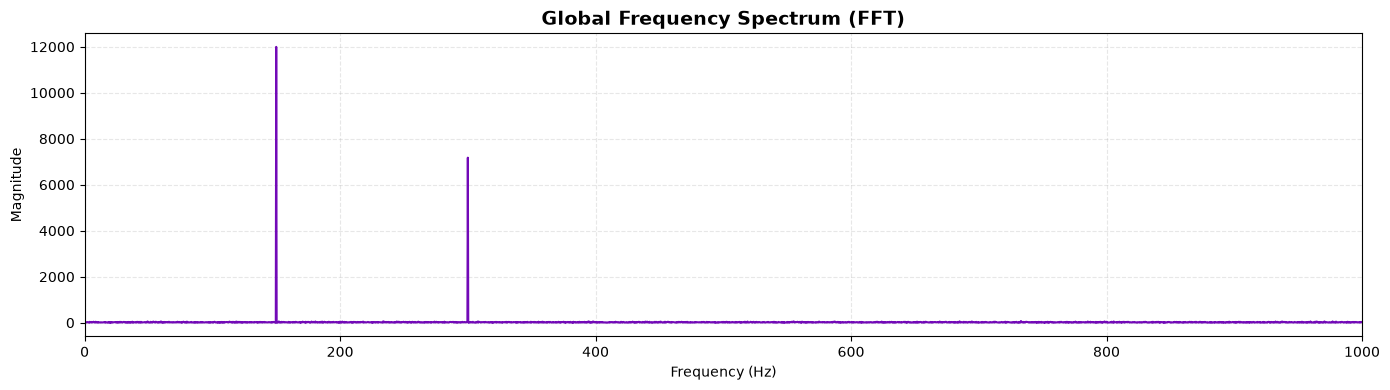

In [13]:
# Compute 1D FFT
fft_vals = np.fft.fft(audio)
fft_magnitude = np.abs(fft_vals)
freq_bins = np.fft.fftfreq(len(audio), 1 / sample_rate)

# Keep only positive frequency spectrum
half_len = len(freq_bins) // 2
pos_freqs = freq_bins[:half_len]
pos_mag = fft_magnitude[:half_len]

plt.figure(figsize=(14, 4))
plt.plot(pos_freqs, pos_mag, color='#7209b7', linewidth=1.5)
plt.title("Global Frequency Spectrum (FFT)", fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 1000) # Zoom into speech pitch fundamentals
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

--- 
### 6. Short-Time Fourier Transform (Spectrogram)

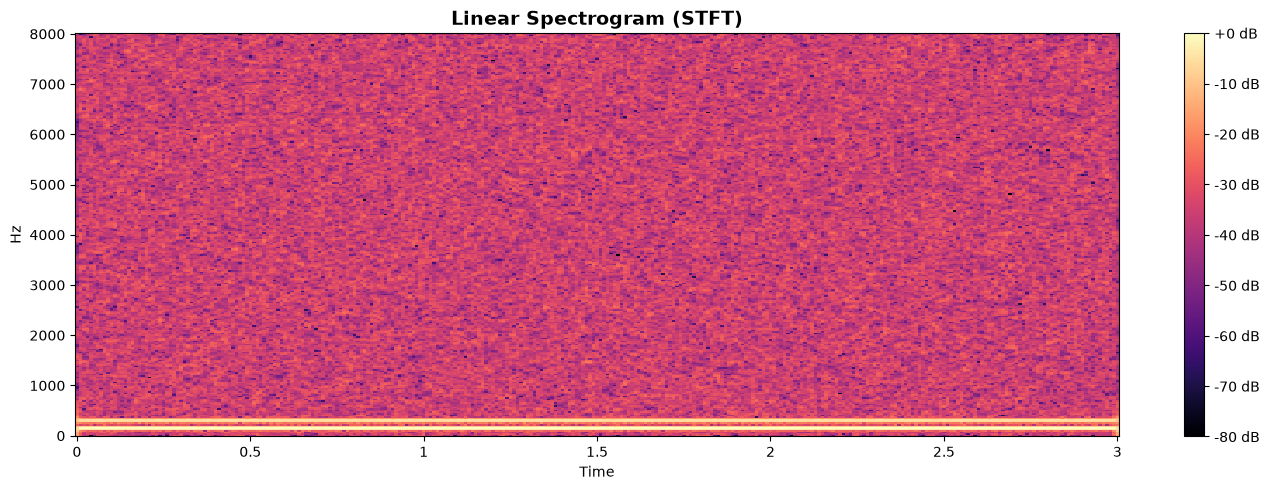

In [15]:
# Compute STFT
stft = librosa.stft(audio, n_fft=512, hop_length=160)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(stft_db, sr=sample_rate, hop_length=160, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Linear Spectrogram (STFT)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

--- 
### 7. Mel Spectrogram (Mel Scale)

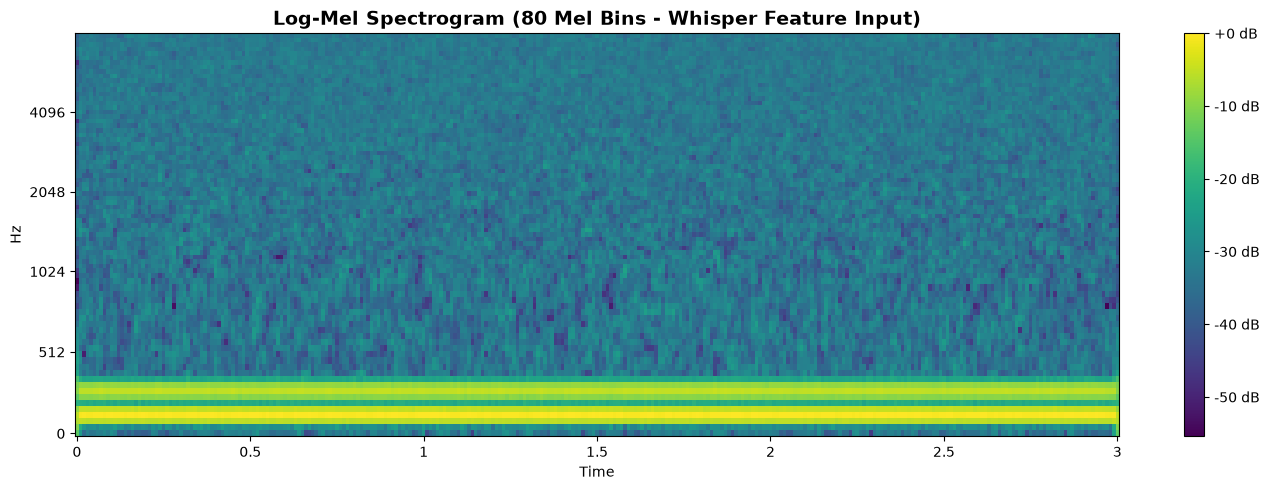

In [17]:
# Compute 80-channel Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=80, n_fft=512, hop_length=160)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(mel_db, sr=sample_rate, hop_length=160, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Mel Spectrogram (80 Mel Bins - Whisper Feature Input)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

--- 
### 8. Comparative Analysis: Male vs. Female Voices

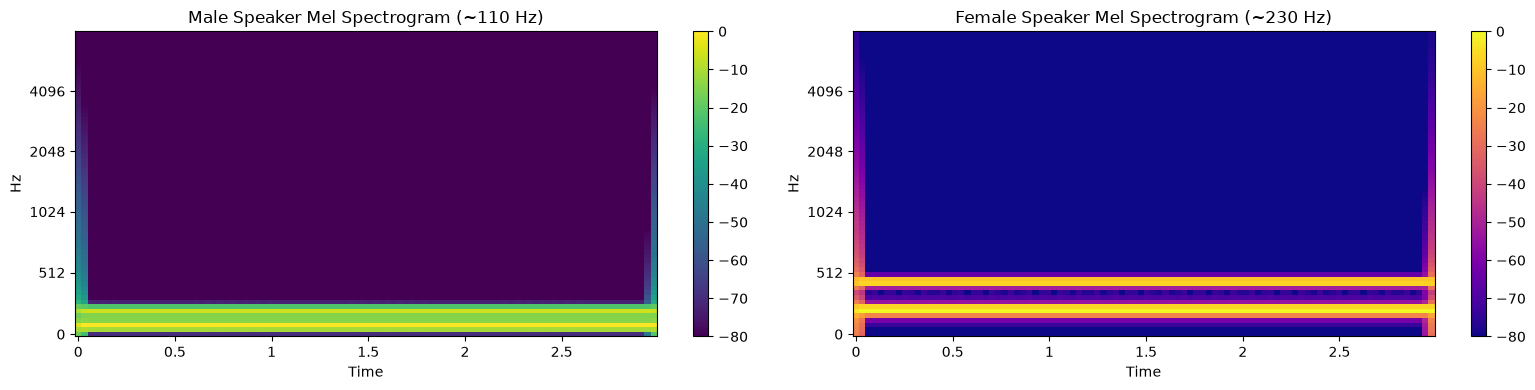

In [19]:
# Synthetic Male Voice (~110 Hz Fundamental)
male_voice = 0.6 * np.sin(2 * np.pi * 110 * t) + 0.3 * np.sin(2 * np.pi * 220 * t)
# Synthetic Female Voice (~230 Hz Fundamental)
female_voice = 0.6 * np.sin(2 * np.pi * 230 * t) + 0.3 * np.sin(2 * np.pi * 460 * t)

mel_male = librosa.power_to_db(librosa.feature.melspectrogram(y=male_voice, sr=sample_rate, n_mels=80), ref=np.max)
mel_female = librosa.power_to_db(librosa.feature.melspectrogram(y=female_voice, sr=sample_rate, n_mels=80), ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
img1 = librosa.display.specshow(mel_male, sr=sample_rate, x_axis='time', y_axis='mel', ax=axes[0], cmap='viridis')
axes[0].set_title("Male Speaker Mel Spectrogram (~110 Hz)")
fig.colorbar(img1, ax=axes[0])

img2 = librosa.display.specshow(mel_female, sr=sample_rate, x_axis='time', y_axis='mel', ax=axes[1], cmap='plasma')
axes[1].set_title("Female Speaker Mel Spectrogram (~230 Hz)")
fig.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.show()

--- 
### 9. Comparative Analysis: Music vs. Speech

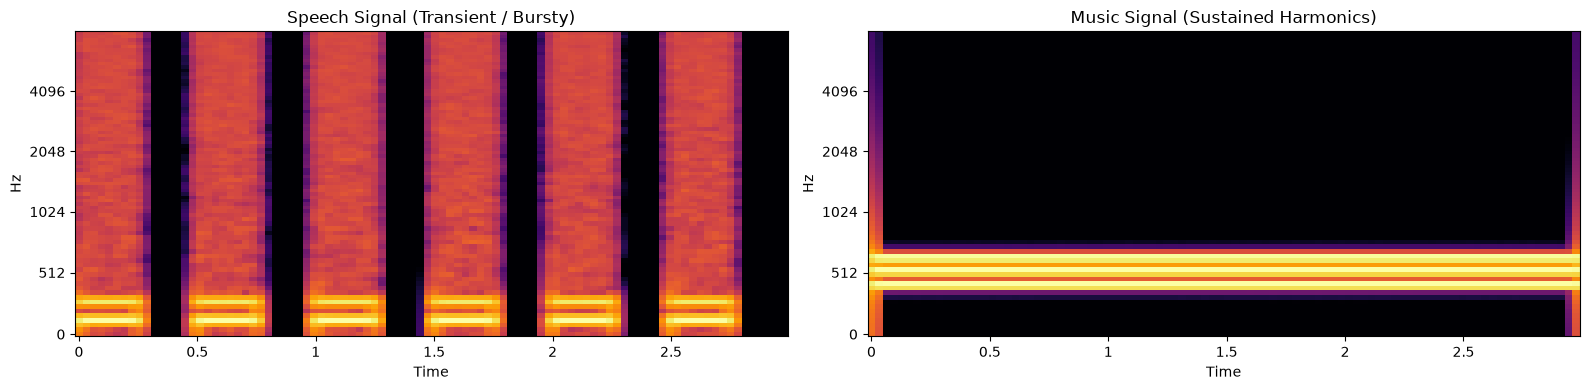

In [21]:
# Speech (Bursty, intermittent silence)
speech_sim = audio * (np.sin(2 * np.pi * 2 * t) > 0).astype(float)
# Music (Continuous harmonic chords)
music_sim = 0.3 * (np.sin(2 * np.pi * 440 * t) + np.sin(2 * np.pi * 554.37 * t) + np.sin(2 * np.pi * 659.25 * t))

mel_speech = librosa.power_to_db(librosa.feature.melspectrogram(y=speech_sim, sr=sample_rate, n_mels=80), ref=np.max)
mel_music = librosa.power_to_db(librosa.feature.melspectrogram(y=music_sim, sr=sample_rate, n_mels=80), ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
librosa.display.specshow(mel_speech, sr=sample_rate, x_axis='time', y_axis='mel', ax=axes[0], cmap='inferno')
axes[0].set_title("Speech Signal (Transient / Bursty)")

librosa.display.specshow(mel_music, sr=sample_rate, x_axis='time', y_axis='mel', ax=axes[1], cmap='inferno')
axes[1].set_title("Music Signal (Sustained Harmonics)")

plt.tight_layout()
plt.show()

--- 
### 10. Save Processed Audio

In [23]:
output_dir = "processed_output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "processed_speech_16k.wav")
sf.write(output_path, audio, sample_rate)
print(f"Successfully saved processed audio to: {output_path}")

Successfully saved processed audio to: processed_output/processed_speech_16k.wav


--- 
## Live Class Questions & Answers

1. **Why can't computers work directly on raw speech audio?**
   * *Answer:* Raw waveforms are 1D high-dimensional continuous arrays with immense variation across volume, speed, and pitch. A single word spoken twice produces completely unaligned numeric arrays.
2. **Why do we need Sampling?**
   * *Answer:* Physical audio is a continuous continuous wave. Digital computers can only store discrete numbers at fixed sample intervals ($f_s$).
3. **What is the difference between Waveform and Spectrogram?**
   * *Answer:* Waveforms represent amplitude over time (1D). Spectrograms represent frequency magnitudes across time frames (2D Heatmap Image).
4. **Why is Mel Spectrogram preferred over standard Spectrogram?**
   * *Answer:* Human auditory perception is non-linear (logarithmic). The Mel scale expands lower frequencies where human speech and vowels are concentrated and compresses higher frequencies.
5. **If sample rate drops from 16 kHz to 4 kHz, what happens to speech recognition accuracy?**
   * *Answer:* According to Nyquist-Shannon theorem, 4 kHz can only capture frequencies up to 2 kHz, cutting off critical high-frequency fricative phonemes ('s', 'f', 'sh', 'th'). Accuracy drops drastically.
6. **Why is FFT alone insufficient for speech recognition?**
   * *Answer:* FFT aggregates all frequencies across the entire recording into a single static spectrum, completely discarding the time dimension.

--- 
## Mini Lab Exercise (10 Minutes)

### Instructions:
1. Load an audio clip of 5–10 seconds using `librosa.load`.
2. Print its sample rate ($sr$) and total duration.
3. Plot its time-domain waveform using `plt.plot`.
4. Compute and plot its linear Spectrogram using `librosa.stft`.
5. Compute and plot its 80-channel Mel Spectrogram using `librosa.feature.melspectrogram`.
6. Compare two distinct recordings (e.g. Male vs Female or Speech vs Music) and write a 2-line observation.

**Deliverable:** Export plot images with a 2-line comparative summary.